In [330]:
words = open('names.txt', 'r').read().splitlines()

In [331]:
words[:10]

['emma',
 'olivia',
 'ava',
 'isabella',
 'sophia',
 'charlotte',
 'mia',
 'amelia',
 'harper',
 'evelyn']

# **1. Karpathy'nin İngilizce names.txt dosyasıyla başla, Türkçe veri görev 5'te gelecek. Bigram'ları önce Python dictionary ile, sonra 27x27 torch tensor'da say. Tabloyu videodaki gibi görselleştir. (3:03 - 24:02)**

In [332]:
for w in words[:1]:
  for ch1, ch2 in zip(w, w[1:]):
    print(ch1, ch2)

e m
m m
m a


In [333]:
w

'emma'

In [334]:
list(w)

['e', 'm', 'm', 'a']

In [335]:
for w in words[:3]:
  chs = ['<S>'] + list(w) + ['<E>']
  for ch1, ch2 in zip(chs, chs[1:]):
    print(ch1, ch2)

<S> e
e m
m m
m a
a <E>
<S> o
o l
l i
i v
v i
i a
a <E>
<S> a
a v
v a
a <E>


In [336]:
b = {} #bu sırayı sayacak ve tutacak bir tuple
for w in words[:3]:
  chs = ['<S>'] + list(w) + ['<E>']
  for ch1, ch2 in zip(chs, chs[1:]):
    bigram = (ch1, ch2)
    b[bigram] = b.get(bigram, 0) + 1
    print(ch1, ch2)

<S> e
e m
m m
m a
a <E>
<S> o
o l
l i
i v
v i
i a
a <E>
<S> a
a v
v a
a <E>


In [337]:
b

{('<S>', 'e'): 1,
 ('e', 'm'): 1,
 ('m', 'm'): 1,
 ('m', 'a'): 1,
 ('a', '<E>'): 3,
 ('<S>', 'o'): 1,
 ('o', 'l'): 1,
 ('l', 'i'): 1,
 ('i', 'v'): 1,
 ('v', 'i'): 1,
 ('i', 'a'): 1,
 ('<S>', 'a'): 1,
 ('a', 'v'): 1,
 ('v', 'a'): 1}

In [338]:
b = {} #şimdi tüm dataset için yapıyoruz
for w in words:
  chs = ['<S>'] + list(w) + ['<E>']
  for ch1, ch2 in zip(chs, chs[1:]):
    bigram = (ch1, ch2)
    b[bigram] = b.get(bigram, 0) + 1

In [339]:
b

{('<S>', 'e'): 1531,
 ('e', 'm'): 769,
 ('m', 'm'): 168,
 ('m', 'a'): 2590,
 ('a', '<E>'): 6640,
 ('<S>', 'o'): 394,
 ('o', 'l'): 619,
 ('l', 'i'): 2480,
 ('i', 'v'): 269,
 ('v', 'i'): 911,
 ('i', 'a'): 2445,
 ('<S>', 'a'): 4410,
 ('a', 'v'): 834,
 ('v', 'a'): 642,
 ('<S>', 'i'): 591,
 ('i', 's'): 1316,
 ('s', 'a'): 1201,
 ('a', 'b'): 541,
 ('b', 'e'): 655,
 ('e', 'l'): 3248,
 ('l', 'l'): 1345,
 ('l', 'a'): 2623,
 ('<S>', 's'): 2055,
 ('s', 'o'): 531,
 ('o', 'p'): 95,
 ('p', 'h'): 204,
 ('h', 'i'): 729,
 ('<S>', 'c'): 1542,
 ('c', 'h'): 664,
 ('h', 'a'): 2244,
 ('a', 'r'): 3264,
 ('r', 'l'): 413,
 ('l', 'o'): 692,
 ('o', 't'): 118,
 ('t', 't'): 374,
 ('t', 'e'): 716,
 ('e', '<E>'): 3983,
 ('<S>', 'm'): 2538,
 ('m', 'i'): 1256,
 ('a', 'm'): 1634,
 ('m', 'e'): 818,
 ('<S>', 'h'): 874,
 ('r', 'p'): 14,
 ('p', 'e'): 197,
 ('e', 'r'): 1958,
 ('r', '<E>'): 1377,
 ('e', 'v'): 463,
 ('v', 'e'): 568,
 ('l', 'y'): 1588,
 ('y', 'n'): 1826,
 ('n', '<E>'): 6763,
 ('b', 'i'): 217,
 ('i', 'g'): 428,


In [340]:
sorted(b.items(), key = lambda kv: -kv[1])

[(('n', '<E>'), 6763),
 (('a', '<E>'), 6640),
 (('a', 'n'), 5438),
 (('<S>', 'a'), 4410),
 (('e', '<E>'), 3983),
 (('a', 'r'), 3264),
 (('e', 'l'), 3248),
 (('r', 'i'), 3033),
 (('n', 'a'), 2977),
 (('<S>', 'k'), 2963),
 (('l', 'e'), 2921),
 (('e', 'n'), 2675),
 (('l', 'a'), 2623),
 (('m', 'a'), 2590),
 (('<S>', 'm'), 2538),
 (('a', 'l'), 2528),
 (('i', '<E>'), 2489),
 (('l', 'i'), 2480),
 (('i', 'a'), 2445),
 (('<S>', 'j'), 2422),
 (('o', 'n'), 2411),
 (('h', '<E>'), 2409),
 (('r', 'a'), 2356),
 (('a', 'h'), 2332),
 (('h', 'a'), 2244),
 (('y', 'a'), 2143),
 (('i', 'n'), 2126),
 (('<S>', 's'), 2055),
 (('a', 'y'), 2050),
 (('y', '<E>'), 2007),
 (('e', 'r'), 1958),
 (('n', 'n'), 1906),
 (('y', 'n'), 1826),
 (('k', 'a'), 1731),
 (('n', 'i'), 1725),
 (('r', 'e'), 1697),
 (('<S>', 'd'), 1690),
 (('i', 'e'), 1653),
 (('a', 'i'), 1650),
 (('<S>', 'r'), 1639),
 (('a', 'm'), 1634),
 (('l', 'y'), 1588),
 (('<S>', 'l'), 1572),
 (('<S>', 'c'), 1542),
 (('<S>', 'e'), 1531),
 (('j', 'a'), 1473),
 (

In [341]:
import torch

In [342]:
N = torch.zeros((28,28), dtype=torch.int32)

In [343]:
chars = sorted(list(set(''.join(words))))
stoi = {s:i for i,s in enumerate(chars)}

In [344]:
stoi

{'a': 0,
 'b': 1,
 'c': 2,
 'd': 3,
 'e': 4,
 'f': 5,
 'g': 6,
 'h': 7,
 'i': 8,
 'j': 9,
 'k': 10,
 'l': 11,
 'm': 12,
 'n': 13,
 'o': 14,
 'p': 15,
 'q': 16,
 'r': 17,
 's': 18,
 't': 19,
 'u': 20,
 'v': 21,
 'w': 22,
 'x': 23,
 'y': 24,
 'z': 25}

In [345]:
stoi['<S>'] = 26
stoi['<E>'] = 27

In [346]:
for w in words:
  chs = ['<S>'] + list(w) + ['<E>']
  for ch1, ch2 in zip(chs, chs[1:]):
    ix1 = stoi[ch1]
    ix2 = stoi[ch2]
    N[ix1, ix2] += 1

In [347]:
N

tensor([[ 556,  541,  470, 1042,  692,  134,  168, 2332, 1650,  175,  568, 2528,
         1634, 5438,   63,   82,   60, 3264, 1118,  687,  381,  834,  161,  182,
         2050,  435,    0, 6640],
        [ 321,   38,    1,   65,  655,    0,    0,   41,  217,    1,    0,  103,
            0,    4,  105,    0,    0,  842,    8,    2,   45,    0,    0,    0,
           83,    0,    0,  114],
        [ 815,    0,   42,    1,  551,    0,    2,  664,  271,    3,  316,  116,
            0,    0,  380,    1,   11,   76,    5,   35,   35,    0,    0,    3,
          104,    4,    0,   97],
        [1303,    1,    3,  149, 1283,    5,   25,  118,  674,    9,    3,   60,
           30,   31,  378,    0,    1,  424,   29,    4,   92,   17,   23,    0,
          317,    1,    0,  516],
        [ 679,  121,  153,  384, 1271,   82,  125,  152,  818,   55,  178, 3248,
          769, 2675,  269,   83,   14, 1958,  861,  580,   69,  463,   50,  132,
         1070,  181,    0, 3983],
        [ 242,    0,

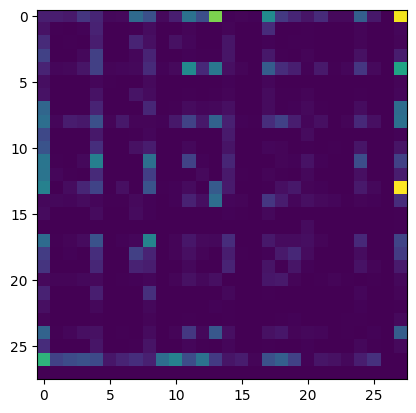

In [348]:
import matplotlib.pyplot as plt
%matplotlib inline
plt.imshow(N)

In [349]:
itos = {i:s for s,i in stoi.items()}
itos

{0: 'a',
 1: 'b',
 2: 'c',
 3: 'd',
 4: 'e',
 5: 'f',
 6: 'g',
 7: 'h',
 8: 'i',
 9: 'j',
 10: 'k',
 11: 'l',
 12: 'm',
 13: 'n',
 14: 'o',
 15: 'p',
 16: 'q',
 17: 'r',
 18: 's',
 19: 't',
 20: 'u',
 21: 'v',
 22: 'w',
 23: 'x',
 24: 'y',
 25: 'z',
 26: '<S>',
 27: '<E>'}

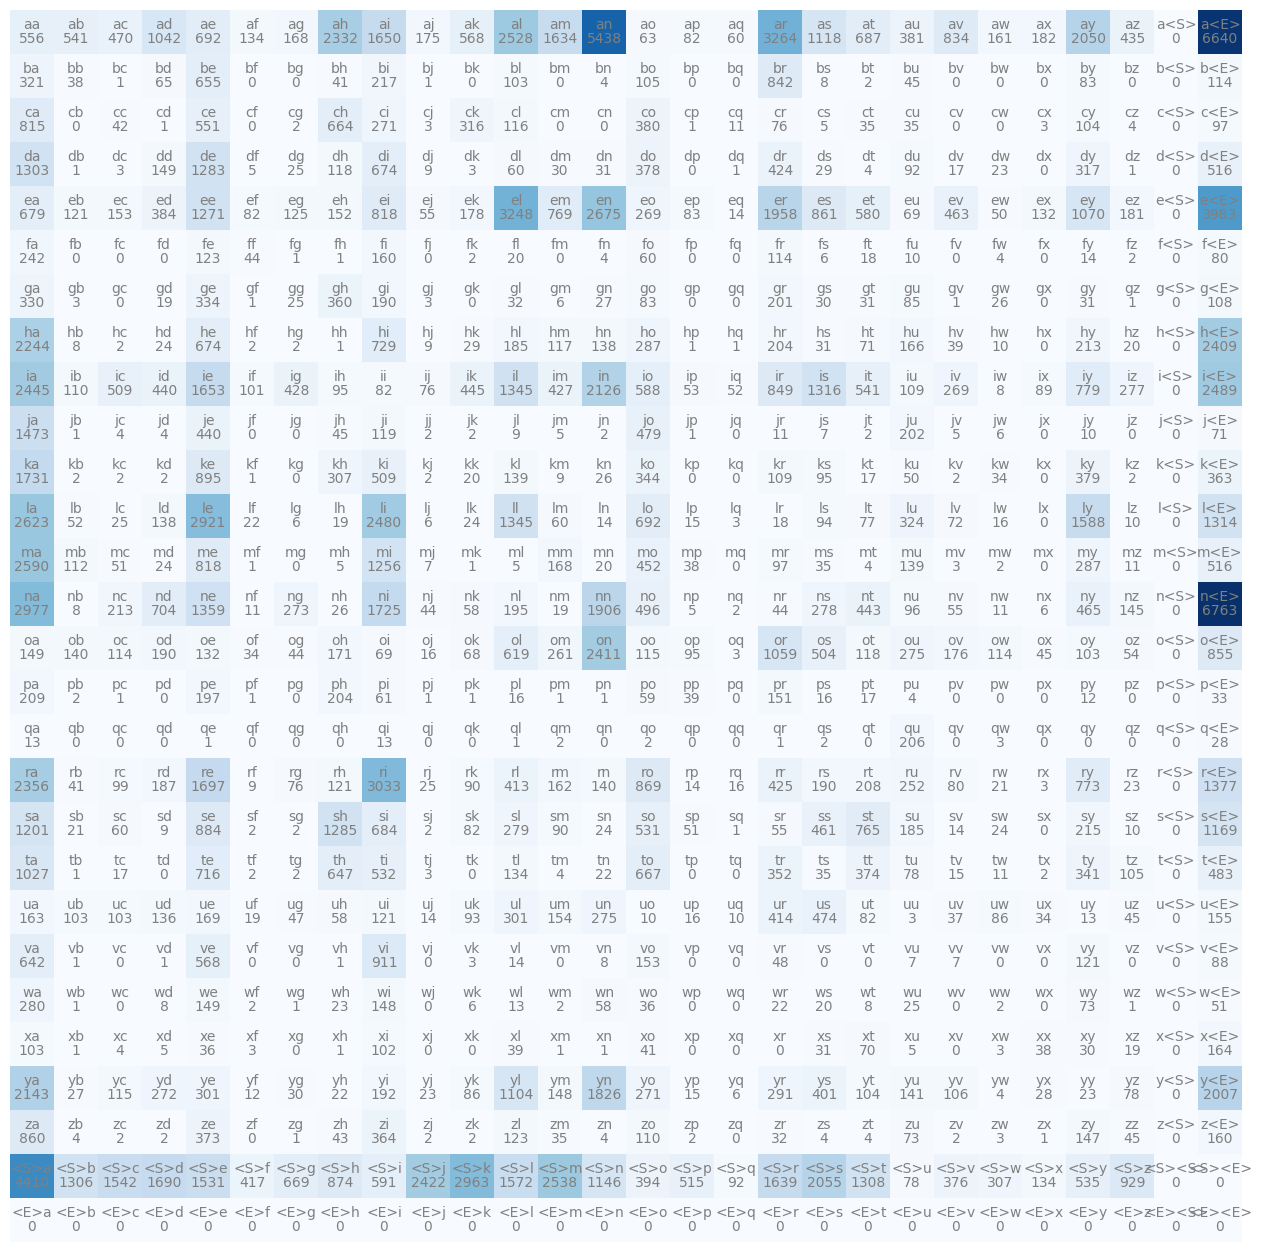

In [350]:
import matplotlib.pyplot as plt
%matplotlib inline

plt.figure(figsize=(16,16))
plt.imshow(N, cmap='Blues')
for i in range(28):
  for j in range(28):
    chstr = itos[i] + itos[j]
    plt.text(j, i, chstr, ha="center", va="bottom", color='gray')
    plt.text(j, i, N[i, j].item(), ha="center", va="top", color='gray')
plt.axis('off');

In [351]:
N = torch.zeros((27,27), dtype=torch.int32)

In [352]:
chars = sorted(list(set(''.join(words))))
stoi = {s:i+1 for i,s in enumerate(chars)}
stoi['.'] = 0
itos = {i:s for s,i in stoi.items()}

In [353]:
stoi

{'a': 1,
 'b': 2,
 'c': 3,
 'd': 4,
 'e': 5,
 'f': 6,
 'g': 7,
 'h': 8,
 'i': 9,
 'j': 10,
 'k': 11,
 'l': 12,
 'm': 13,
 'n': 14,
 'o': 15,
 'p': 16,
 'q': 17,
 'r': 18,
 's': 19,
 't': 20,
 'u': 21,
 'v': 22,
 'w': 23,
 'x': 24,
 'y': 25,
 'z': 26,
 '.': 0}

In [354]:
for w in words:
  chs = ['.'] + list(w) + ['.']
  for ch1, ch2 in zip(chs, chs[1:]):
    ix1 = stoi[ch1]
    ix2 = stoi[ch2]
    N[ix1, ix2] += 1

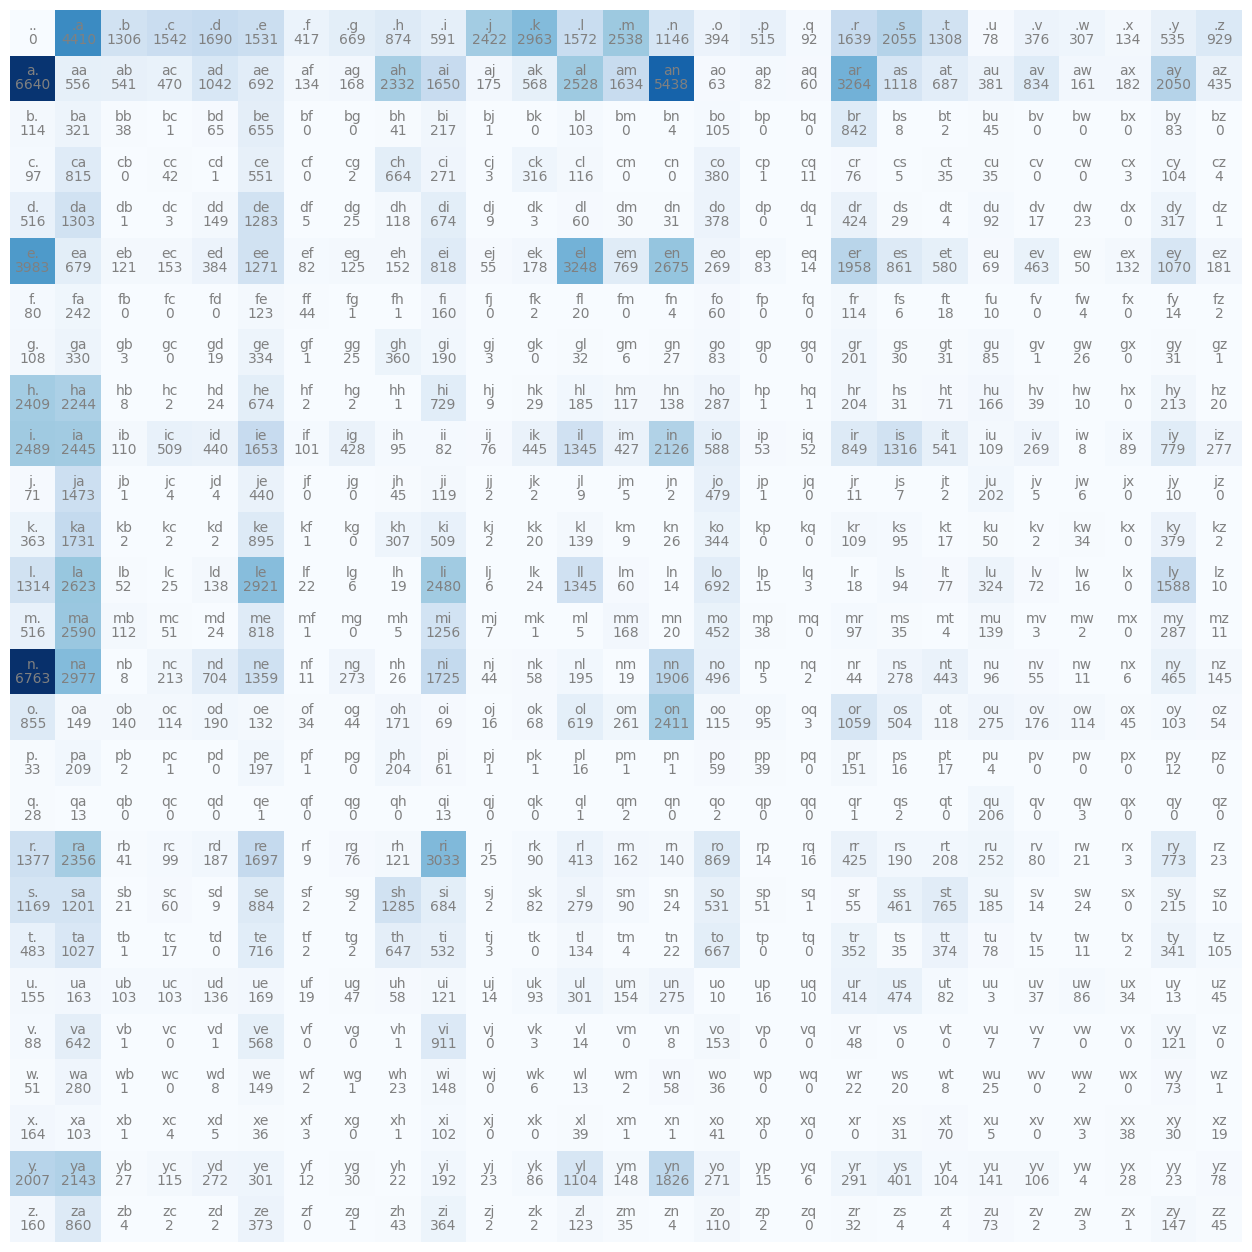

In [355]:
import matplotlib.pyplot as plt
%matplotlib inline

plt.figure(figsize=(16,16))
plt.imshow(N, cmap='Blues')
for i in range(27):
  for j in range(27):
    chstr = itos[i] + itos[j]
    plt.text(j, i, chstr, ha="center", va="bottom", color='gray')
    plt.text(j, i, N[i, j].item(), ha="center", va="top", color='gray')
plt.axis('off');

# **2. Sayım tablosunu satır satır olasılıklara çevir ve modelden yeni isimler örnekle. Broadcasting'e dikkat: videodaki keepdim tuzağı, sessizce yanlış model üreten cinsten. (24:02 - 50:14)**

In [356]:
N[0]

tensor([   0, 4410, 1306, 1542, 1690, 1531,  417,  669,  874,  591, 2422, 2963,
        1572, 2538, 1146,  394,  515,   92, 1639, 2055, 1308,   78,  376,  307,
         134,  535,  929], dtype=torch.int32)

In [357]:
p = N[0].float()
p = p / p.sum()
p

tensor([0.0000, 0.1377, 0.0408, 0.0481, 0.0528, 0.0478, 0.0130, 0.0209, 0.0273,
        0.0184, 0.0756, 0.0925, 0.0491, 0.0792, 0.0358, 0.0123, 0.0161, 0.0029,
        0.0512, 0.0642, 0.0408, 0.0024, 0.0117, 0.0096, 0.0042, 0.0167, 0.0290])

pytorch multinomial egzersiz

In [358]:
g = torch.Generator().manual_seed(2147483647)
p = torch.rand(3, generator = g)
p = p / p.sum()
p

tensor([0.6064, 0.3033, 0.0903])

In [359]:
torch.multinomial(p, num_samples = 100, replacement = True, generator = g)

tensor([1, 1, 2, 0, 0, 2, 1, 1, 0, 0, 0, 1, 1, 0, 0, 1, 1, 0, 0, 1, 0, 2, 0, 0,
        1, 0, 0, 1, 0, 0, 0, 1, 1, 1, 0, 1, 1, 0, 0, 1, 1, 1, 0, 1, 1, 0, 1, 1,
        0, 2, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 1, 0, 0, 0, 0, 0, 0, 0, 0, 1, 0,
        0, 1, 0, 0, 0, 0, 0, 0, 0, 1, 2, 0, 0, 0, 0, 0, 0, 1, 0, 0, 2, 0, 1, 0,
        0, 1, 1, 1])

-----------------------

In [360]:
p = N[0].float()
p = p / p.sum()
p

tensor([0.0000, 0.1377, 0.0408, 0.0481, 0.0528, 0.0478, 0.0130, 0.0209, 0.0273,
        0.0184, 0.0756, 0.0925, 0.0491, 0.0792, 0.0358, 0.0123, 0.0161, 0.0029,
        0.0512, 0.0642, 0.0408, 0.0024, 0.0117, 0.0096, 0.0042, 0.0167, 0.0290])

In [361]:
g = torch.Generator().manual_seed(2147483647)
ix = torch.multinomial(p, num_samples = 1, replacement = True, generator = g).item()
print(ix)
itos[ix]

3


'c'

In [362]:
g = torch.Generator().manual_seed(2147483647)

for i in range(50):
  out = []
  ix = 0
  while True:
    p = N[ix].float()
    p = p / p.sum()
    #p = torch.ones(27) / 27.0 <- bu uniform distribution versiyonu. p'yi N[ix] e göre verdiğimizde biagrama göre distibution etmiş oluyoruz ve daha isme benzer sonuclar cikiyor
    ix = torch.multinomial(p, num_samples = 1, replacement = True, generator = g).item()
    out.append(itos[ix])
    if ix == 0:
      break
  print(''.join(out))

cexze.
momasurailezitynn.
konimittain.
llayn.
ka.
da.
staiyaubrtthrigotai.
moliellavo.
ke.
teda.
ka.
emimmsade.
enkaviyny.
ftlspihinivenvorhlasu.
dsor.
br.
jol.
pen.
aisan.
ja.
feniee.
zem.
deru.
firit.
gaikajahahbevare.
kiysthelenaririenah.
keen.
x.
al.
kal.
thavazeeromysos.
laitenimieegariseriyen.
k.
illeleldole.
meenisammigama.
mmin.
asharin.
alcalar.
jayn.
asaz.
selanely.
chay.
rana.
ai.
yviamisashougen.
l.
beyncaro.
allan.
annutetoradrilia.
rddeman.


In [363]:
P = N.float()

In [364]:
P.sum()

tensor(228146.)

In [365]:
P.shape

torch.Size([27, 27])

In [366]:
print(P.sum(1, keepdim = True))
print(P.sum(1, keepdim = True).shape)

tensor([[32033.],
        [33885.],
        [ 2645.],
        [ 3532.],
        [ 5496.],
        [20423.],
        [  905.],
        [ 1927.],
        [ 7616.],
        [17701.],
        [ 2900.],
        [ 5040.],
        [13958.],
        [ 6642.],
        [18327.],
        [ 7934.],
        [ 1026.],
        [  272.],
        [12700.],
        [ 8106.],
        [ 5570.],
        [ 3135.],
        [ 2573.],
        [  929.],
        [  697.],
        [ 9776.],
        [ 2398.]])
torch.Size([27, 1])


Burada yapmaya çalıştığımız şey tüm satırların toplamını 1 yapabilmek. yani N matrisini satır bazında olasılık dağılımına dönüştürmek. Her bir satırı kendi toplamın bölmeliyiz.

Broadcasting,  makine öğrenmesi ve doğrusal cebir kütüphanelerinde (PyTorch, NumPy, JAX,
TensorFlow) iki farklı boyuttaki tensör arasında bellekte tek bir bayt fazladan kopyalama yapmadan eleman bazlı matematiksel işlem yapılmasını sağlayan çekirdek mekanizmadır.

Normalde biz 5000x512 lik bir embedding matrisine 512 boyutlu bir bias vektörü eklemek istersek 2 farklı senaryo ile karşılaşırız:

1- (torch.repeat veya np.tile): Bias vektörünü 5000 defa bellekte alt alta kopyalayıp 5000x512 lik matris oluşturmak. sonuc = cache kirlenir, memory bandwith tükenir.

2- (Broadcasting): Bu kopyalamayı fiziksel bellekte yapmaz. boyutu 1 olan eksenleri sanal olarak esnetir


Bir tensör bellekte aslında 2D veya 3D bir tablo olarak değil, düz 1 boyutlu bir dizi olarak saklanır.

Tensörün şeklini ve o eksende 1 adım atmak için bellekte kaç eleman atlanacağını stride (adım aralığı) belirler.

Örneğin 3 × 3'lük bir matriste:

  • Satırda 1 adım atmak için bellekte 3 eleman atlarsın → stride = (3, 1)

    Eğer boyutu 1 olan bir vektörü (örneğin (3, 1)) broadcast edersen:
    PyTorch o 1 olan eksenin 'stride' değerini 0 yapar!

    Bellek Adresi = (i × stride₀) + (j × stride₁)

  Eğer stride₁ = 0 ise:

    (j × 0) = 0

  Yani j indisi 0,1,2...26 ne olursa olsun, CPU/GPU hep aynı bellek adresini okur. Bellekte hiçbir şey çoğaltılmaz;
  donanım seviyesinde sıfır maliyetle işlem yapılır.

Broadcastingin 3 kuralı

1- Boyut sayısını eşitle (sola 1 eklemek):
  iki tensorun rankı eşit değilse, kucuk ranklının soluna 1 eklenir.
   
   Tensör A: (5, 3)

   Tensör B: (3,) → Başına 1 eklenir: (1, 3) (Bunun nedeni de pytorch boyut karşılaştırması yaparken sağdan taramaya başlıyor.)


2- Sağdan sola uyumluluk kontrolü:
  İki boyutun uyumluluğu kontrol edilir ve iki boyutun uyumlu olması için:
  
  A) Boyutlar eşit olmalı veya

  B) Boyutlardan biri 1 olmalıdır.


3- Çıktı boyutunun hesaplanması:
  İşlem sonucunda oluşan yeni tensörün her boyutu, o eksendeki maksimum boyut olur




  


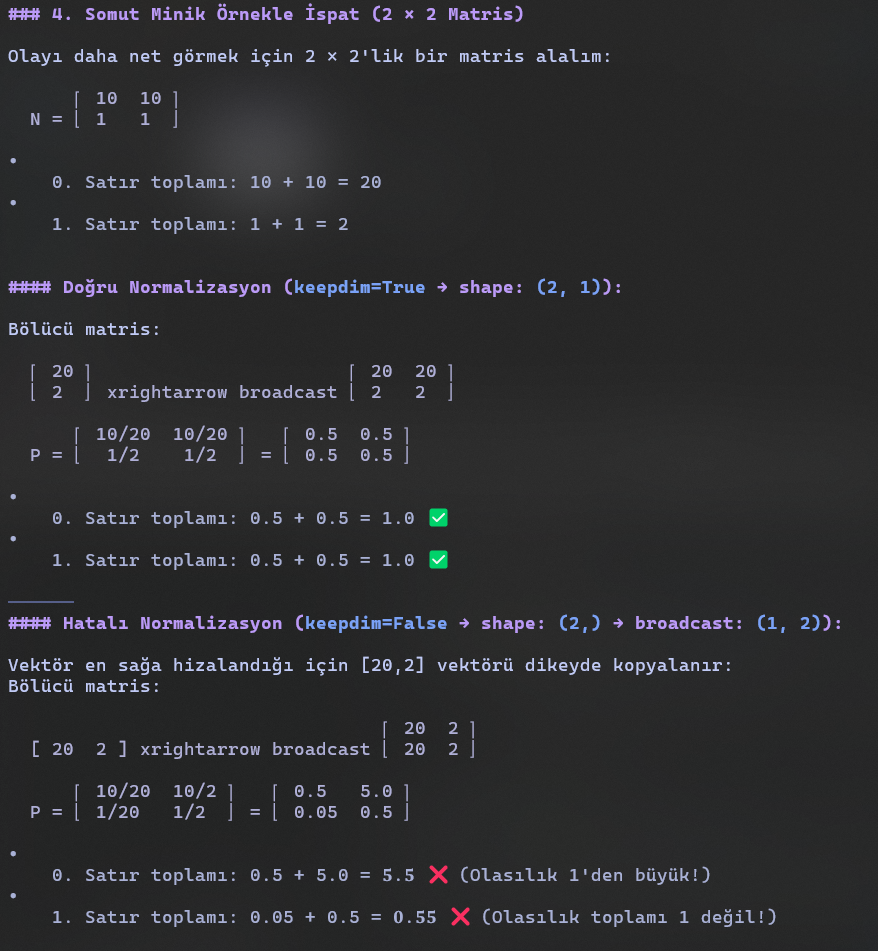

1. P boyutu: (27, 27)

2. P.sum(1) yaptığında sonuç (27,) (1D) çıkar.

3. PyTorch Kural 1'i uygular: (27,) tensörünün başına 1 ekleyerek onu (1, 27) yapar.

4. Bu da Senaryo 1 (Dikey Yayılma) durumunu tetikler.

5. Halbuki bizim satırları normalize etmek için istediğimiz şey Senaryo 2 (Yatay Yayılma - (27, 1)) idi.

  keepdim=True koyduğumuzda PyTorch'a: "Bu ekseni toplayıp 1D'ye düşürme, orada 1 boyutunu bırak ki şekli (27, 1) kalsın" demiş oluyoruz.

Dolayısıyla biz yatay yayılma istediğimiz için keepdim=True kalmalı.

In [367]:
print(P.sum(0, keepdim = True))
print(P.sum(0, keepdim = True).shape)

tensor([[32033., 33885.,  2645.,  3532.,  5496., 20423.,   905.,  1927.,  7616.,
         17701.,  2900.,  5040., 13958.,  6642., 18327.,  7934.,  1026.,   272.,
         12700.,  8106.,  5570.,  3135.,  2573.,   929.,   697.,  9776.,  2398.]])
torch.Size([1, 27])


In [368]:
P = N.float()
P = P / P.sum(1, keepdim = True)

In [369]:
g = torch.Generator().manual_seed(2147483647)

for i in range(5):
  out = []
  ix = 0
  while True:
    p = P[ix]
    #p = N[ix].float()
    #p = p / p.sum()
    #p = torch.ones(27) / 27.0 <- bu uniform distribution versiyonu. p'yi N[ix] e göre verdiğimizde biagrama göre distibution etmiş oluyoruz ve daha isme benzer sonuclar cikiyor

    ix = torch.multinomial(p, num_samples = 1, replacement = True, generator = g).item()
    out.append(itos[ix])
    if ix == 0:
      break
  print(''.join(out))

cexze.
momasurailezitynn.
konimittain.
llayn.
ka.


# **3. Negative log likelihood'u hesapla. Smoothing için sahte sayım ekle. Neden log, neden negatif, neden ortalama: bunu teslim videonda kendi cümlelerinle anlatacaksın. (50:14 - 1:02:57)**

In [370]:
#log(a*b*c) = log(a) + log(b) + log(c)

In [371]:
log_likelihood = 0.0
n = 0

for w in words:
  chs = ['.'] + list(w) + ['.']
  for ch1, ch2 in zip(chs, chs[1:]):
    ix1 = stoi[ch1]
    ix2 = stoi[ch2]
    prob = P[ix1, ix2]

    logprob = torch.log(prob)

    log_likelihood += logprob
    n += 1

    #print(f'{ch1}{ch2}: {prob:.4f} {logprob:.4f}')

print(f'{log_likelihood=}')
nll = -log_likelihood
print(f'{nll=}')
print(f'{nll/n:.4f}')  # bu aslında bizim loss function'ımız.

log_likelihood=tensor(-559891.7500)
nll=tensor(559891.7500)
2.4541


In [372]:
log_likelihood = 0.0
n = 0

for w in ['andrej']:
  chs = ['.'] + list(w) + ['.']
  for ch1, ch2 in zip(chs, chs[1:]):
    ix1 = stoi[ch1]
    ix2 = stoi[ch2]
    prob = P[ix1, ix2]

    logprob = torch.log(prob)

    log_likelihood += logprob
    n += 1

    print(f'{ch1}{ch2}: {prob:.4f} {logprob:.4f}')

print(f'{log_likelihood=}')
nll = -log_likelihood
print(f'{nll=}')
print(f'{nll/n:.4f}')  # bu aslında bizim loss function'ımız.

.a: 0.1377 -1.9829
an: 0.1605 -1.8296
nd: 0.0384 -3.2594
dr: 0.0771 -2.5620
re: 0.1336 -2.0127
ej: 0.0027 -5.9171
j.: 0.0245 -3.7098
log_likelihood=tensor(-21.2735)
nll=tensor(21.2735)
3.0391


In [373]:
log_likelihood = 0.0
n = 0
#ŞİMDİ burada daha önce hiç görülmemiş bir kombinasyon ekliyorum 'jq'. Bunun 0 olmasından dolayı likelihood sonucu eksi sonsuz
#çıkacak. NLL ise sonsuz çıkacak.
for w in ['andrejq']:
  chs = ['.'] + list(w) + ['.']
  for ch1, ch2 in zip(chs, chs[1:]):
    ix1 = stoi[ch1]
    ix2 = stoi[ch2]
    prob = P[ix1, ix2]

    logprob = torch.log(prob)

    log_likelihood += logprob
    n += 1

    print(f'{ch1}{ch2}: {prob:.4f} {logprob:.4f}')

print(f'{log_likelihood=}')
nll = -log_likelihood
print(f'{nll=}')
print(f'{nll/n:.4f}')  # bu aslında bizim loss function'ımız.

.a: 0.1377 -1.9829
an: 0.1605 -1.8296
nd: 0.0384 -3.2594
dr: 0.0771 -2.5620
re: 0.1336 -2.0127
ej: 0.0027 -5.9171
jq: 0.0000 -inf
q.: 0.1029 -2.2736
log_likelihood=tensor(-inf)
nll=tensor(inf)
inf


In [374]:
# Bu yüzden her kombinasyona N matrisine +1 ekliyoruz. Bu sayede hiçbir komb. daha önce görülmemiş olmayacak. Dolayısıyla sonsuz
# sonuc cıkmayacak. Buna Smoothing deniyor. Buraya ne kadar büyük değer eklersem, elimdeki olasılık dağılımı o kadar uniform
#distribution'a benzer.
P = (N+1).float()
P = P / P.sum(1, keepdim = True)

In [375]:
g = torch.Generator().manual_seed(2147483647)

for i in range(5):
  out = []
  ix = 0
  while True:
    p = P[ix]
    #p = N[ix].float()
    #p = p / p.sum()
    #p = torch.ones(27) / 27.0 <- bu uniform distribution versiyonu. p'yi N[ix] e göre verdiğimizde biagrama göre distribution etmiş oluyoruz ve daha isme benzer sonuclar cikiyor

    ix = torch.multinomial(p, num_samples = 1, replacement = True, generator = g).item()
    out.append(itos[ix])
    if ix == 0:
      break
  print(''.join(out))

cexze.
momasurailezitynn.
konimittain.
llayn.
ka.


In [376]:
log_likelihood = 0.0
n = 0
# Burada sonsuz yerine daha kucuk degerler alacagım. Cunku her kombinasyonu en az bir kere gördüm.
for w in ['andrejq']:
  chs = ['.'] + list(w) + ['.']
  for ch1, ch2 in zip(chs, chs[1:]):
    ix1 = stoi[ch1]
    ix2 = stoi[ch2]
    prob = P[ix1, ix2]

    logprob = torch.log(prob)

    log_likelihood += logprob
    n += 1

    print(f'{ch1}{ch2}: {prob:.4f} {logprob:.4f}')

print(f'{log_likelihood=}')
nll = -log_likelihood
print(f'{nll=}')
print(f'{nll/n:.4f}')  # bu aslında bizim loss function'ımız.

.a: 0.1376 -1.9835
an: 0.1604 -1.8302
nd: 0.0384 -3.2594
dr: 0.0770 -2.5646
re: 0.1334 -2.0143
ej: 0.0027 -5.9004
jq: 0.0003 -7.9817
q.: 0.0970 -2.3331
log_likelihood=tensor(-27.8672)
nll=tensor(27.8672)
3.4834


# **4. Aynı modeli tek katmanlı sinir ağıyla kur: one-hot input, 27x27 weight matrix, softmax, NLL loss, gradient descent döngüsü. Loss'un görev 3'teki sayım modelinin loss'una yaklaştığını göster. Buradaki backward() geçen hafta micrograd'da kendi yazdığın mekanizmanın aynısı. (1:02:57 - 1:54:31)**

In [377]:
#şimdi bigram'lerin trainin setini oluşturuyorum.

xs, ys = [], []

for w in words[:1]:
  chs = ['.'] + list(w) + ['.']
  for ch1, ch2 in zip(chs, chs[1:]):
    ix1 = stoi[ch1]
    ix2 = stoi[ch2]
    print(ch1, ch2)
    xs.append(ix1)
    ys.append(ix2)

xs = torch.tensor(xs)
ys = torch.tensor(ys)

print(xs)
print(ys)

. e
e m
m m
m a
a .
tensor([ 0,  5, 13, 13,  1])
tensor([ 5, 13, 13,  1,  0])


torch.tensor ve torch.Tensor arasındaki fark :
torch.tensor ile oluşturulan bir değişkenin dtype'ı torch.int64 olurken, torch.Tensor ile oluşturulan bir değişkenin dtype'ı torch.float32 oluyor.

In [378]:
import torch.nn.functional as F
xenc = F.one_hot(xs, num_classes = 27).float() #buranın içinde direkt dtype belirtemiyorum o yüzden bunu yaptım.
xenc

tensor([[1., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0.,
         0., 0., 0., 0., 0., 0., 0., 0., 0.],
        [0., 0., 0., 0., 0., 1., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0.,
         0., 0., 0., 0., 0., 0., 0., 0., 0.],
        [0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 1., 0., 0., 0., 0.,
         0., 0., 0., 0., 0., 0., 0., 0., 0.],
        [0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 1., 0., 0., 0., 0.,
         0., 0., 0., 0., 0., 0., 0., 0., 0.],
        [0., 1., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0.,
         0., 0., 0., 0., 0., 0., 0., 0., 0.]])

In [379]:
xenc.shape

torch.Size([5, 27])

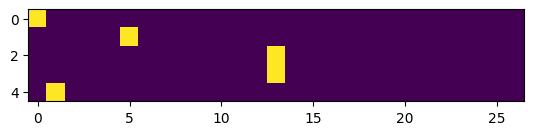

In [380]:
plt.imshow(xenc)

In [381]:
# onehot torch.int64 dtype'lı bir değişken aldığı için, oluşturduğu xenc de torch.int64 oluyor.
xenc.dtype


torch.float32

In [382]:
W = torch.rand((27,27)) #normal distribution'dan rastgele 27x27 ağırlık matrisi ürettik.

xenc @ W # mat mul yaptık (5, 27) @ (27, 27) = (5, 27)


tensor([[0.7545, 0.4756, 0.2473, 0.1362, 0.4409, 0.9314, 0.6992, 0.5272, 0.3275,
         0.9729, 0.3049, 0.7023, 0.5502, 0.3104, 0.3233, 0.5420, 0.8331, 0.6577,
         0.6773, 0.8138, 0.2355, 0.5224, 0.6205, 0.5136, 0.8972, 0.7466, 0.2801],
        [0.3413, 0.1067, 0.4510, 0.2035, 0.1500, 0.5732, 0.6179, 0.7172, 0.1767,
         0.2853, 0.9623, 0.9547, 0.7092, 0.4004, 0.9174, 0.3128, 0.8904, 0.3956,
         0.3758, 0.7336, 0.0888, 0.6986, 0.1283, 0.4175, 0.4239, 0.4220, 0.4422],
        [0.3111, 0.8391, 0.9650, 0.2707, 0.5628, 0.2574, 0.6422, 0.0149, 0.1976,
         0.8151, 0.7331, 0.5414, 0.1000, 0.3116, 0.9474, 0.9069, 0.3838, 0.8681,
         0.8864, 0.8298, 0.0685, 0.9344, 0.8500, 0.5527, 0.1292, 0.4881, 0.5440],
        [0.3111, 0.8391, 0.9650, 0.2707, 0.5628, 0.2574, 0.6422, 0.0149, 0.1976,
         0.8151, 0.7331, 0.5414, 0.1000, 0.3116, 0.9474, 0.9069, 0.3838, 0.8681,
         0.8864, 0.8298, 0.0685, 0.9344, 0.8500, 0.5527, 0.1292, 0.4881, 0.5440],
        [0.8714, 0.5516,

In [383]:
(xenc @ W)[3, 13]

tensor(0.3116)

In [384]:
xenc[3]

tensor([0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 1., 0., 0., 0., 0.,
        0., 0., 0., 0., 0., 0., 0., 0., 0.])

In [385]:
W[:, 13]

tensor([0.3104, 0.7691, 0.5456, 0.4908, 0.4308, 0.4004, 0.7397, 0.4116, 0.4599,
        0.6121, 0.3297, 0.7993, 0.3731, 0.3116, 0.8695, 0.0319, 0.4879, 0.3944,
        0.0113, 0.8837, 0.9455, 0.0490, 0.6590, 0.1846, 0.7844, 0.0172, 0.3406])

In [386]:
(xenc[3] * W[:, 13]).sum()  # (xenc @ W)[3, 13] buna eşit

tensor(0.3116)

burada mat mul bize; i. input için üretilen ağırlık satırını bize W matrisinden çeker. Biz one-hot encoding yaptığımız için zaten bir harf'in indisi neyse onu sütunu 1, diğer 26 sütunu 0 yapıyoruz. mat mul yaptığımızda zaten 0 lar birbirini götürüyor ve cikti olarak sadece bizim indisimize etki eden agirligi görüyoruz. çünkü harflere etki eden weightler encoding'teki 0 sütunları tarafından yutuluyor. Burada direkt W[i] yapmamamızın sebebi ise diferansiyellenebilirliği korumak ve paralelleştirme ile gpu'da hız kazanmak. (tek tek for döngüsüyle i. indisin agirligini cekmek yerine direkt islem yapiyoruz.)

In [387]:
xs

tensor([ 0,  5, 13, 13,  1])

In [388]:
ys

tensor([ 5, 13, 13,  1,  0])

In [389]:
# random şekilde 27 neuron'un da weightlerini üretiyoruz. her neuron 27 input alıyor.
g= torch.Generator().manual_seed(2147483647+1)
W = torch.randn((27, 27), generator = g)

In [390]:
# forward-pass
xenc = xenc = F.one_hot(xs, num_classes = 27).float() # input to the network : one-hot encoding
logits = xenc @ W  # predict log-counts
counts = logits.exp() # counts, N matrisiyle aynı.
probs = counts / counts.sum(1, keepdim = True) # probs for next character
#bu yukarıdaki son iki satır softmax fonksiyonunun ta kendisi.

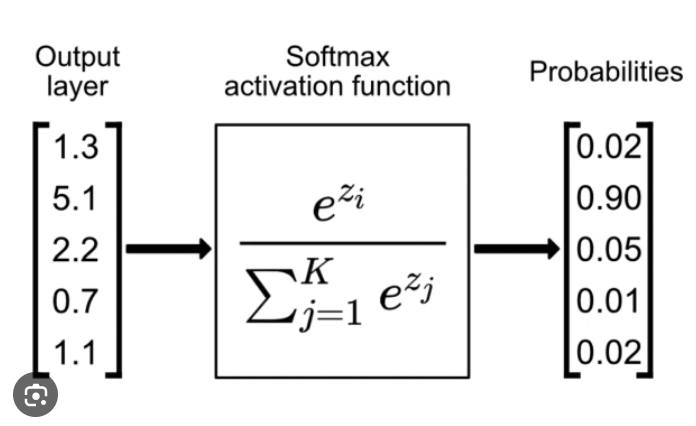

In [391]:
probs.shape

torch.Size([5, 27])

In [392]:
probs[2].sum()

tensor(1.0000)

In [393]:
nlls = torch.zeros(5)
for i in range(5):
  #i-th bigram:
  x = xs[i].item() # input karakterin indexi
  y = ys[i].item() # label karakterin indexi
  print('----------------')
  print(f'biagram example {i+1}: {itos[x]}{itos[y]} (indexes {x},{y})')
  print('input to the neural net:', x)
  print('output probabilities from the neural net:', probs[i])
  print('label (actual next character):', y)
  p = probs[i, y]
  print('probabilities assigned by the net to the correct character:', p.item())
  logp = torch.log(p)
  print('log likelihood:', logp.item())
  nll = -logp
  print('negative log likelihood:', nll.item())
  nlls[i] = nll

print('================')
print('average negative log likelihood, i.e. loss =', nlls.mean().item())

----------------
biagram example 1: .e (indexes 0,5)
input to the neural net: 0
output probabilities from the neural net: tensor([0.0049, 0.0959, 0.0281, 0.0703, 0.0961, 0.0573, 0.0241, 0.0135, 0.0093,
        0.1416, 0.0225, 0.0217, 0.0513, 0.0106, 0.0097, 0.0291, 0.0229, 0.0273,
        0.0325, 0.0275, 0.0446, 0.0501, 0.0214, 0.0093, 0.0120, 0.0354, 0.0310])
label (actual next character): 5
probabilities assigned by the net to the correct character: 0.05734505504369736
log likelihood: -2.858668565750122
negative log likelihood: 2.858668565750122
----------------
biagram example 2: em (indexes 5,13)
input to the neural net: 5
output probabilities from the neural net: tensor([0.0426, 0.0113, 0.0266, 0.0507, 0.2370, 0.0580, 0.0421, 0.0094, 0.0136,
        0.0297, 0.0044, 0.0782, 0.1028, 0.0146, 0.0172, 0.0288, 0.0263, 0.0319,
        0.0248, 0.0210, 0.0063, 0.0057, 0.0309, 0.0269, 0.0298, 0.0089, 0.0205])
label (actual next character): 13
probabilities assigned by the net to the correct

optimizasyon kısmı

In [394]:
xs

tensor([ 0,  5, 13, 13,  1])

In [395]:
ys

tensor([ 5, 13, 13,  1,  0])

In [396]:
# random şekilde 27 neuron'un da weightlerini üretiyoruz. her neuron 27 input alıyor.
g= torch.Generator().manual_seed(2147483647)
W = torch.randn((27, 27), generator = g, requires_grad=True)

In [397]:
# forward-pass
xenc = F.one_hot(xs, num_classes = 27).float() # input to the network : one-hot encoding
logits = xenc @ W  # predict log-counts
counts = logits.exp() # counts, N matrisiyle aynı.
probs = counts / counts.sum(1, keepdim = True) # probs for next character
#bu yukarıdaki son iki satır softmax fonksiyonunun ta kendisi.
loss = -probs[torch.arange(5), ys].log().mean()

In [398]:
# backward pass

W.grad = None #set zero to the grad
loss.backward() # pytorch zaten bizim geçen hafta yaptığımız yapı gibi yani graphlar gibi computation yaptığı için tüm gerekli bilgileri tutuyor zaten. o yüzden direkt backward() fonksiyonunu çalıştırabildim

In [399]:
W.grad

tensor([[ 0.0121,  0.0020,  0.0025,  0.0008,  0.0034, -0.1975,  0.0005,  0.0046,
          0.0027,  0.0063,  0.0016,  0.0056,  0.0018,  0.0016,  0.0100,  0.0476,
          0.0121,  0.0005,  0.0050,  0.0011,  0.0068,  0.0022,  0.0006,  0.0040,
          0.0024,  0.0307,  0.0292],
        [-0.1970,  0.0017,  0.0079,  0.0020,  0.0121,  0.0062,  0.0217,  0.0026,
          0.0025,  0.0010,  0.0205,  0.0017,  0.0198,  0.0022,  0.0046,  0.0041,
          0.0082,  0.0016,  0.0180,  0.0106,  0.0093,  0.0062,  0.0010,  0.0066,
          0.0131,  0.0101,  0.0018],
        [ 0.0000,  0.0000,  0.0000,  0.0000,  0.0000,  0.0000,  0.0000,  0.0000,
          0.0000,  0.0000,  0.0000,  0.0000,  0.0000,  0.0000,  0.0000,  0.0000,
          0.0000,  0.0000,  0.0000,  0.0000,  0.0000,  0.0000,  0.0000,  0.0000,
          0.0000,  0.0000,  0.0000],
        [ 0.0000,  0.0000,  0.0000,  0.0000,  0.0000,  0.0000,  0.0000,  0.0000,
          0.0000,  0.0000,  0.0000,  0.0000,  0.0000,  0.0000,  0.0000,  0.0000

In [400]:
# update-parameters
W.data += -0.1 * W.grad

daha duzenli bir format ile optimizasyon

In [401]:
# dataset olusturma
xs, ys = [], []

for w in words:
  chs = ['.'] + list(w) + ['.']
  for ch1, ch2 in zip(chs, chs[1:]):
    ix1 = stoi[ch1]
    ix2 = stoi[ch2]
    xs.append(ix1)
    ys.append(ix2)
xs = torch.tensor(xs)
ys = torch.tensor(ys)
num = xs.nelement()
print('number of examples:', num)

# network'u başlatalım
g= torch.Generator().manual_seed(2147483647)
W = torch.randn((27, 27), generator = g, requires_grad=True)

number of examples: 228146


In [402]:
# gradient descent
for k in range(100): #BURAYI 100 KERE İTERE ETMEYİ DENE !!!!

  # forward-pass
  xenc = F.one_hot(xs, num_classes = 27).float() # input to the network : one-hot encoding
  logits = xenc @ W  # predict log-counts
  counts = logits.exp() # counts, N matrisiyle aynı.
  probs = counts / counts.sum(1, keepdim = True) # probs for next character
  loss = -probs[torch.arange(num), ys].log().mean()
  print(loss.item())

  # backward pass
  W.grad = None #set zero to the grad
  loss.backward()

  # update-parameters
  W.data += -50.0 * W.grad # LEARNİNG RATE İ 50 YAPIP DENE !!!!

3.758953809738159
3.371100425720215
3.1540427207946777
3.020373582839966
2.927711009979248
2.8604023456573486
2.8097288608551025
2.7701022624969482
2.7380728721618652
2.711496591567993
2.6890032291412354
2.6696884632110596
2.65293025970459
2.638277769088745
2.6253879070281982
2.613990545272827
2.60386323928833
2.5948219299316406
2.5867116451263428
2.5794036388397217
2.572789192199707
2.5667762756347656
2.5612878799438477
2.5562586784362793
2.551633596420288
2.547365665435791
2.543415069580078
2.5397486686706543
2.536336660385132
2.5331544876098633
2.5301804542541504
2.5273969173431396
2.5247862339019775
2.522334337234497
2.520028829574585
2.517857789993286
2.515810966491699
2.513878345489502
2.512052059173584
2.5103237628936768
2.5086872577667236
2.5071349143981934
2.5056614875793457
2.5042612552642822
2.5029289722442627
2.5016608238220215
2.5004520416259766
2.4992988109588623
2.498197317123413
2.4971446990966797
2.4961376190185547
2.495173692703247
2.4942493438720703
2.493363380432129

# **5. İnternetten bir Türkçe isim listesi bul (açık kaynak listeler var, GitHub'da arayabilirsin) ve iki modeli de bu veriyle tekrar koştur. Alfabeyi Türkçe karakterlerle genişlet (ç, ğ, ı, ö, ş, ü). Modelin ürettiği isimlerden örnekleri ve loss'u göster.**

In [403]:
# Türkçe isim datasetini internetten çek ve hazırla
import urllib.request, csv, io

BASE = 'https://raw.githubusercontent.com/eoner/turkce_isimler/master/'
MIN_SAYIM = 50  # bu eşiğin altındakiler yazım hatası / çok nadir isimler = gürültü

def tr_lower(s):
  # Türkçe küçültme: önce I -> ı ve İ -> i, sonra lower(). Sırayı bozarsam 'İ' -> 'i̇' (nokta artığı) olur.
  return s.replace('I', 'ı').replace('İ', 'i').lower()

TR_ALFABE = set('abcçdefgğhıijklmnoöprsştuüvyz')  # 29 harf

isimler = set()
for dosya in ['tr_isim_erkek.csv', 'tr_isim_kadin.csv']:
  metin = urllib.request.urlopen(BASE + dosya).read().decode('utf-8')
  for satir in csv.reader(io.StringIO(metin)):
    if len(satir) != 2 or not satir[1].isdigit():
      continue  # '[isim],[sayi]' başlık satırı
    isim, sayi = tr_lower(satir[0].strip()), int(satir[1])
    if sayi >= MIN_SAYIM and len(isim) > 1 and set(isim) <= TR_ALFABE:
      isimler.add(isim)  # set: aynı isim iki dosyada da varsa bir kere sayılsın

words_tr = sorted(isimler)
with open('turkce_isimler.txt', 'w', encoding='utf-8') as f:
  for isim in words_tr:
    print(isim, file=f)

print('isim sayısı:', len(words_tr))
words_tr[:10]

isim sayısı: 17304


['aba',
 'ababekir',
 'abamüslim',
 'abamüslüm',
 'abas',
 'abbas',
 'abbasali',
 'abbaskulu',
 'abbaz',
 'abbut']

In [404]:
# alfabeyi datadan çıkar (İngilizce versiyondaki chars/stoi/itos'un aynısı, sadece 27 -> 30)
chars_tr = sorted(list(set(''.join(words_tr))))
stoi_tr = {s:i+1 for i,s in enumerate(chars_tr)}
stoi_tr['.'] = 0
itos_tr = {i:s for s,i in stoi_tr.items()}

V = len(itos_tr)  # vocab size: 29 harf + '.' = 30
print(V)
print(''.join(chars_tr))

30
abcdefghijklmnoprstuvyzçöüğış


In [405]:
import torch
N_tr = torch.zeros((V, V), dtype=torch.int32)

for w in words_tr:
  chs = ['.'] + list(w) + ['.']
  for ch1, ch2 in zip(chs, chs[1:]):
    ix1 = stoi_tr[ch1]
    ix2 = stoi_tr[ch2]
    N_tr[ix1, ix2] += 1

N_tr

tensor([[   0, 1371,  912,  379,  449,  739,  772,  997, 1330,  402,   25,  655,
          203, 1854, 1296,   96,  214,  623, 1804,  599,  121,  264,  277,  681,
           99,  125,  193,   30,   22,  772],
        [1653,   64,  565,  166,  576,   31,  304,   62, 1014,  208,    4,  354,
          919,  587, 2240,    1,  102,  941,  421,  816,   10,  224,  933,  661,
           52,    0,    0,   92,    2,  179],
        [  41,  610,   36,    0,  242,  908,    0,    0,    9,  458,    0,    1,
            8,    0,    1,   50,    0,   69,    0,    6,  133,    0,    2,    0,
            0,    1,   54,    1,    9,    0],
        [   4,  417,    7,   13,   21,  373,    0,    2,    9,  253,    0,    0,
           15,   15,    2,   25,    0,   18,    0,    2,   47,    5,    1,    0,
            0,    1,   23,    0,   44,    0],
        [ 106,  501,    4,    0,  225,  768,    1,    0,    8,  913,    0,    5,
           19,    7,    5,   88,    0,   57,    2,    4,  412,    9,    9,    0,
      

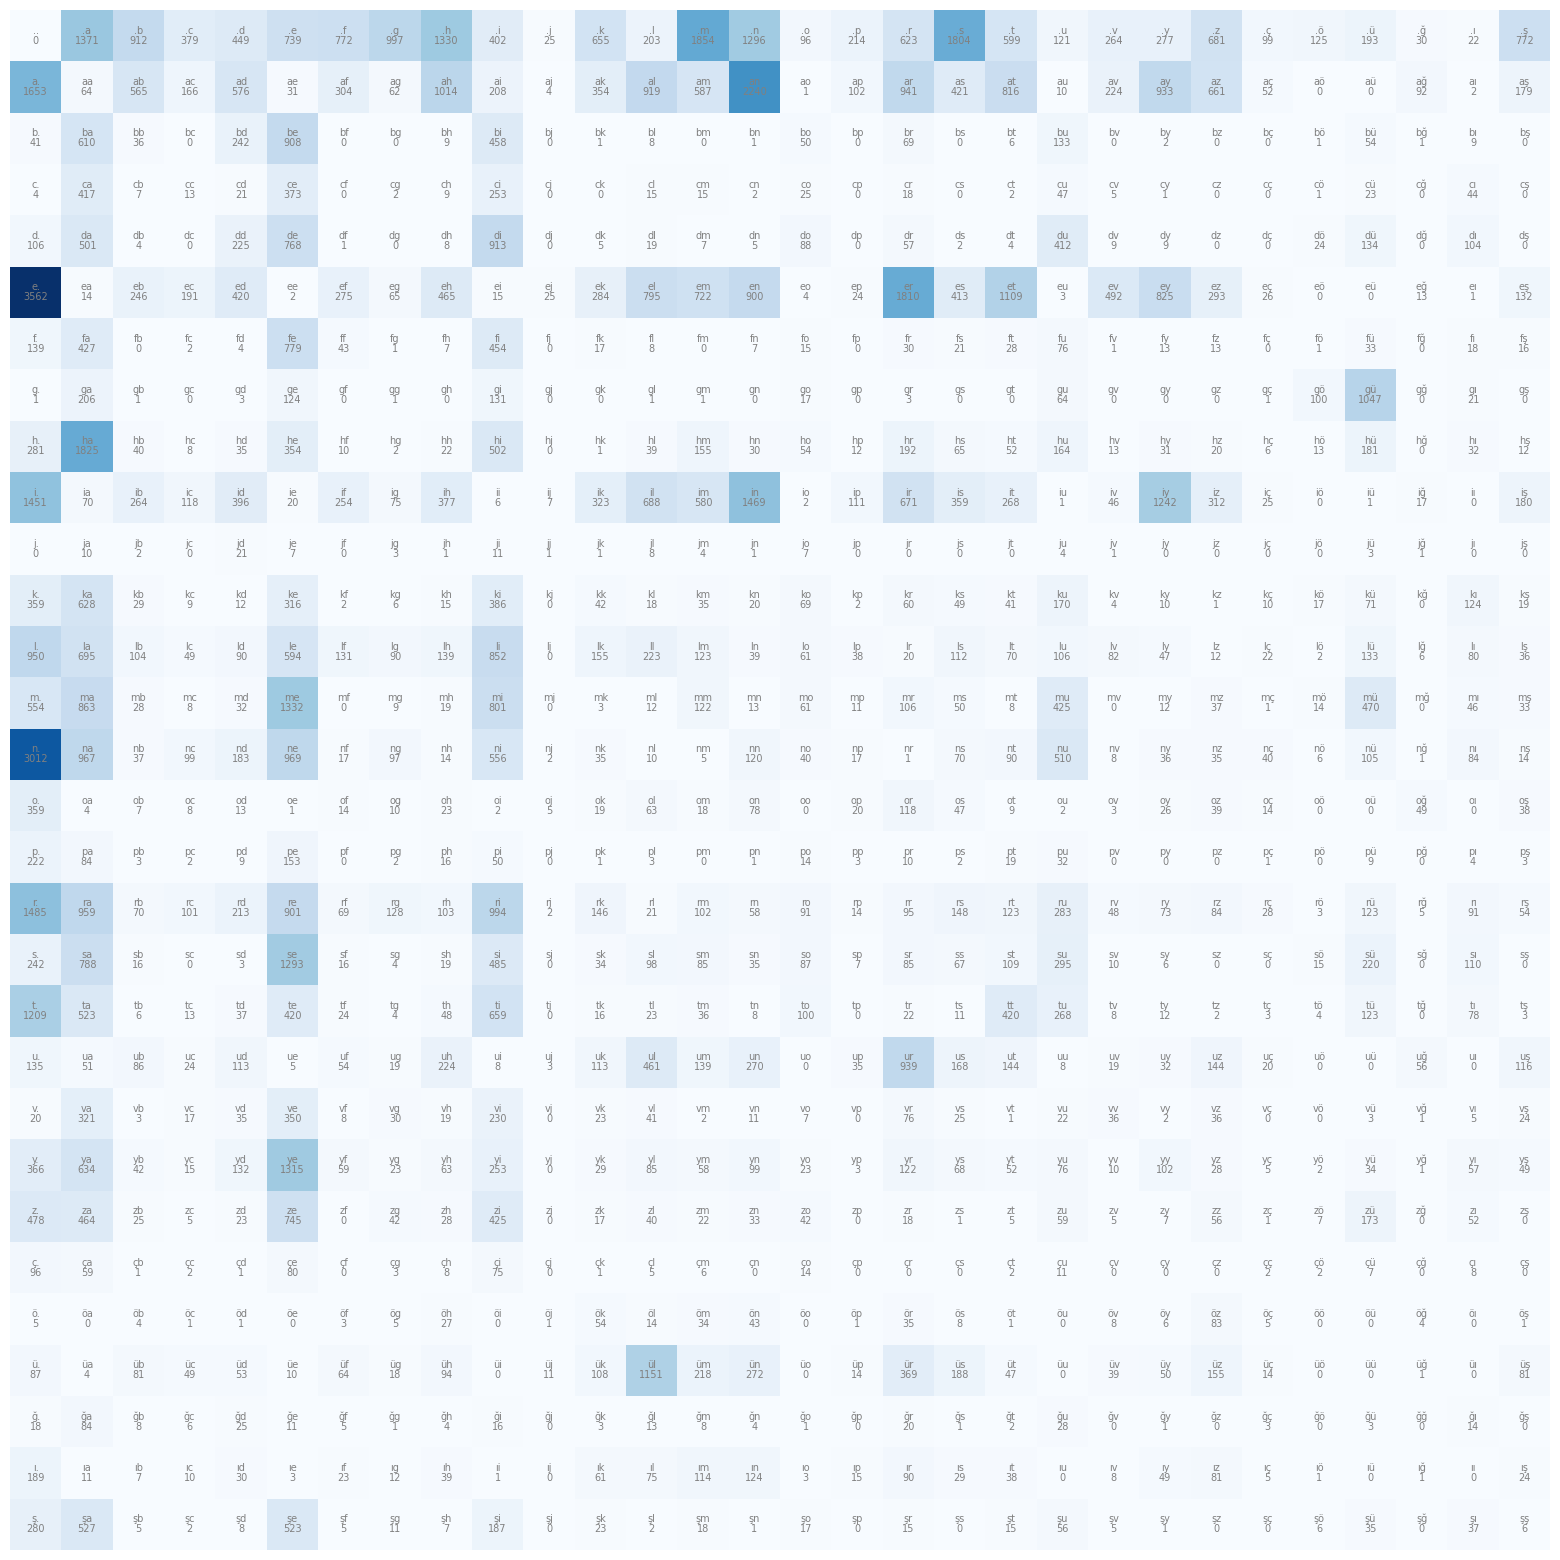

In [406]:
import matplotlib.pyplot as plt


plt.figure(figsize=(20,20))
plt.imshow(N_tr, cmap='Blues')
for i in range(V):
  for j in range(V):
    chstr = itos_tr[i] + itos_tr[j]
    plt.text(j, i, chstr, ha="center", va="bottom", color='gray', fontsize=7)
    plt.text(j, i, N_tr[i, j].item(), ha="center", va="top", color='gray', fontsize=7)
plt.axis('off');

In [407]:
# smoothing'li olasılık matrisi (görev 3'teki (N+1) mantığının aynısı)
P_tr = (N_tr+1).float()
P_tr = P_tr / P_tr.sum(1, keepdim = True)

P_tr[0].sum()  # satır toplamı 1 mi, keepdim doğru çalıştı mı kontrolü

tensor(1.0000)

In [408]:
# sayım modelinden örnekleme
g = torch.Generator().manual_seed(2147483647)

for i in range(20):
  out = []
  ix = 0
  while True:
    p = P_tr[ix]
    ix = torch.multinomial(p, num_samples = 1, replacement = True, generator = g).item()
    out.append(itos_tr[ix])
    if ix == 0:
      break
  print(''.join(out))

güsran.
mmuslbi.
me.
seri.
şetmure.
ba.
mek.
e.
hmiye.
zaziyşakiyafa.
it.
ürehahu.
n.
müye.
n.
ahmedadume.
ke.
ay.
marüfjdurildirm.
cersen.


In [409]:
# sayım modelinin loss'u (ortalama negative log likelihood)
log_likelihood = 0.0
n = 0

for w in words_tr:
  chs = ['.'] + list(w) + ['.']
  for ch1, ch2 in zip(chs, chs[1:]):
    prob = P_tr[stoi_tr[ch1], stoi_tr[ch2]]
    log_likelihood += torch.log(prob)
    n += 1

nll = -log_likelihood
print(f'{nll/n:.4f}')  # SAYIM MODELİ LOSS

2.4643


In [410]:
import torch.nn.functional as F
# training set
xs, ys = [], []

for w in words_tr:
  chs = ['.'] + list(w) + ['.']
  for ch1, ch2 in zip(chs, chs[1:]):
    xs.append(stoi_tr[ch1])
    ys.append(stoi_tr[ch2])

xs = torch.tensor(xs)
ys = torch.tensor(ys)
num = xs.nelement()
print('number of examples:', num)

# network'u başlatalım: V neuron, her biri V input alıyor
g = torch.Generator().manual_seed(2147483647)
W_tr = torch.randn((V, V), generator = g, requires_grad=True)

# one-hot'u döngü dışında bir kere hesapla, her iterasyonda aynı şey
xenc = F.one_hot(xs, num_classes = V).float()
xenc.shape

number of examples: 123019


torch.Size([123019, 30])

In [411]:
# gradient descent
for k in range(200):

  # forward-pass
  logits = xenc @ W_tr                              # log-counts tahmini
  counts = logits.exp()                             # counts, N_tr matrisiyle aynı rolde
  probs = counts / counts.sum(1, keepdim = True)    # softmax
  loss = -probs[torch.arange(num), ys].log().mean() + 0.01*(W_tr**2).mean()

  if k % 20 == 0 or k == 199:
    print(k, loss.item())

  # backward pass
  W_tr.grad = None
  loss.backward()

  # update-parameters
  W_tr.data += -50 * W_tr.grad

0 3.997344970703125
20 2.6045942306518555
40 2.536971092224121
60 2.517077684402466
80 2.5076820850372314
100 2.5023303031921387
120 2.4989583492279053
140 2.4967093467712402
160 2.4951484203338623
180 2.494025707244873
199 2.493229627609253


In [412]:
# sinir ağından örnekleme (aynı seed, sayım modeliyle karşılaştırılabilsin diye)
g = torch.Generator().manual_seed(2147483647)

for i in range(20):
  out = []
  ix = 0
  while True:
    xenc_i = F.one_hot(torch.tensor([ix]), num_classes = V).float()
    logits = xenc_i @ W_tr
    counts = logits.exp()
    p = counts / counts.sum(1, keepdim = True)

    ix = torch.multinomial(p, num_samples = 1, replacement = True, generator = g).item()
    out.append(itos_tr[ix])
    if ix == 0:
      break
  print(''.join(out))

güsran.
mmuslbi.
me.
seri.
şhimure.
ba.
mek.
e.
hmiye.
zaziyşakiyafa.
it.
ürehahu.
n.
müye.
n.
ahmedadume.
ke.
jize.
füfjdurildirm.
cersen.
